# GPT and Autoregressive Models

## Start with the problem: produce the next item using only the available prefix

Imagine completing the phrase “The puppy carried the”. A model must choose a distribution over plausible next tokens from the prefix it has seen. It cannot inspect the correct continuation first and still claim to have predicted it.

An **autoregressive model** builds a sequence through conditional predictions. Each new item depends on earlier items. GPT-style language models implement this pattern with Transformer blocks whose self-attention is causal: a position reads its current input and earlier inputs, while later positions are hidden.

The core lesson is a relationship among inputs, targets, probabilities, and information flow. It is not a claim that predicting likely text verifies facts or supplies a particular reasoning capability. The architecture provides a computation; data and training determine its behavior.

We will shift a token sequence, calculate its likelihood and loss, inspect gradients, and compare generation procedures. The [code companion](32_GPT_and_Autoregressive_Models.ipynb) first checks one causal forward/backward pass, then completes a trained tiny-Transformer project with a sentence-level holdout and generation. [BERT and Encoder Models](31_BERT_and_Encoder_Models_Notes.ipynb) provides the bidirectional contrast.


## Follow the generation loop

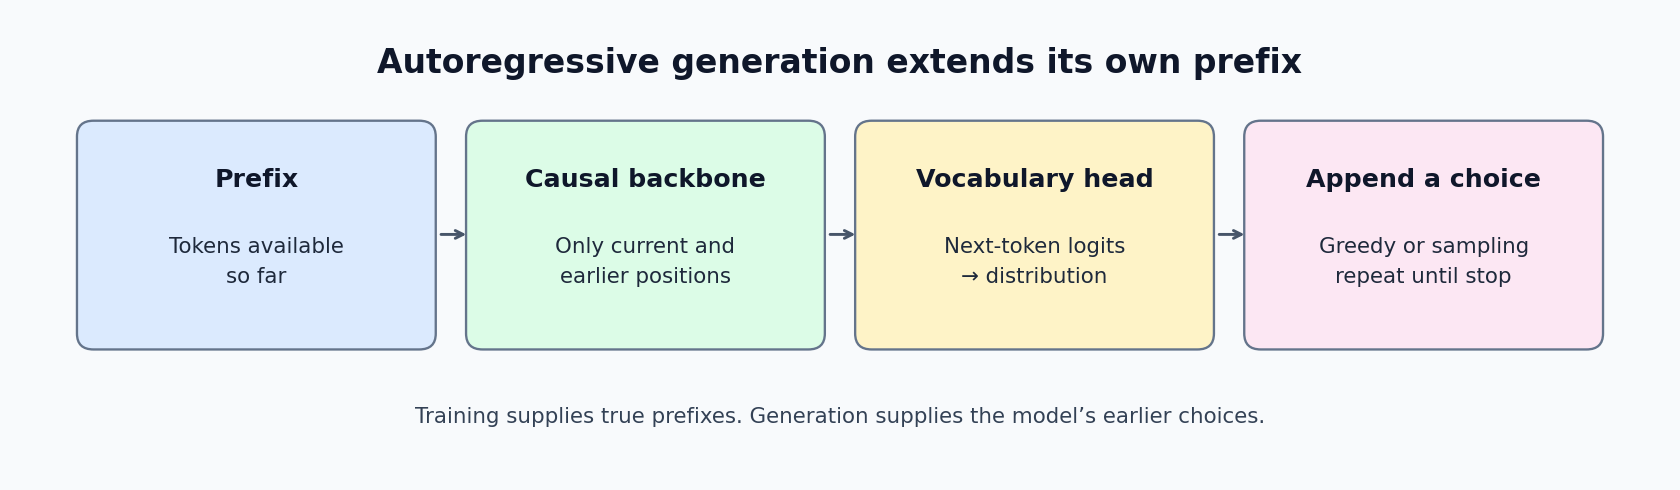

| Stage | What it supplies |
| --- | --- |
| Prefix | Tokens already available |
| Token and position representations | Numerical features for those positions |
| Causal Transformer stack | Prefix-aware hidden states |
| Vocabulary head | One logit per possible next token |
| Selection rule | A chosen or sampled token |
| Append and repeat | The next prefix |

The head produces scores, not a mandatory next word. The selection rule determines how those scores become an output. Generation continues until an explicit end marker or another stopping rule is satisfied.

A model can be evaluated with known correct prefixes or with its own generated prefixes. These are different settings because its earlier choices can change the context it sees later.


## Factor a sequence into conditional probabilities

For sequence $x_1,\ldots,x_T$, the chain rule gives:

$$p(x_1,\ldots,x_T)=\prod_{t=1}^{T}p(x_t\mid x_{<t}).$$

A start symbol or defined initial condition supplies the beginning. For a three-token target with conditional correct-token probabilities $[0.8,0.6,0.5]$, the joint probability is $0.8(0.6)(0.5)=0.24$.

The total negative log likelihood is:

$$-\ln0.24=-\ln0.8-\ln0.6-\ln0.5\approx1.427116.$$

The mean token loss is approximately 0.475705. Logs turn a product of many small probabilities into a sum, making the training objective easier to accumulate numerically.

The conditional distributions must be defined for the same tokenizer and target sequence. A sequence probability does not measure truth: an incorrect but common sentence can receive high likelihood. Tokenization also changes the number and identity of prediction events, which matters when comparing losses.


## Shift inputs and targets before training

The companion starts from token IDs `[1,2,3,4,5]` and forms inputs `[1,2,3,4]` with targets `[2,3,4,5]`.

| Position | Supplied token | Target token | Permitted supplied prefix |
| --- | --- | --- | --- |
| 0 | 1 | 2 | 1 |
| 1 | 2 | 3 | 1, 2 |
| 2 | 3 | 4 | 1, 2, 3 |
| 3 | 4 | 5 | 1, 2, 3, 4 |

It conditions on the first token and predicts the following four. It does not train a first-token probability from an explicit BOS input in this particular example.

The entire input array is supplied together during training, but the mask prevents earlier positions from using its later entries. Shifting without masking is insufficient: input position one already contains target token two from position zero.

Likewise, masking without shifting can accidentally ask a token representation to reproduce its own input. The two choices jointly define which conditional predictions are learned.


## Inspect the causal rule rather than relying on a class name

For four input positions, the allowed query/key relationships are:

| Query | Key 0 | Key 1 | Key 2 | Key 3 |
| --- | --- | --- | --- | --- |
| 0 | Allow | Block | Block | Block |
| 1 | Allow | Allow | Block | Block |
| 2 | Allow | Allow | Allow | Block |
| 3 | Allow | Allow | Allow | Allow |

The companion constructs an upper-triangular Boolean blocking mask. Its backbone is called `TransformerEncoder`, but the actual causal mask makes the computation a prefix-only self-attention backbone. A library class name alone does not define the language objective.

There is no source-to-target cross-attention in this tiny model. GPT-style “decoder-only” refers here to causal self-attention over a single stream, not to requiring an encoder output at every step.

Causality must hold throughout the stack and any upstream processing. A later mask cannot undo future information that another earlier operation already mixed into the state.


## Trace the companion's numerical interface

The configuration uses vocabulary size seven, model width eight, two heads, one layer, and FFN width sixteen. The position table has five rows; four are used by the input.

| Object | Shape |
| --- | --- |
| Inputs and targets | $(1,4)$ each |
| Content and position embeddings | $(1,4,8)$ each |
| Causal mask | $(4,4)$ |
| Hidden states | $(1,4,8)$ |
| Vocabulary logits | $(1,4,7)$ |
| Flattened loss logits | $(4,7)$ |
| Flattened target IDs | $(4,)$ |

The head maps eight features to seven vocabulary scores. Flattening batch and time dimensions aligns each position's scores with its next-token target. Flattening or transposing the wrong axes can create a valid-sized tensor with incorrect comparisons.

A cross-entropy loss expects logits and class IDs in the chosen layout. A separate softmax is useful for inspecting probabilities, but should not be inserted before a loss that already implements the log-softmax calculation.


## Calculate one next-token distribution and loss

For a three-token teaching vocabulary, take logits $[0,1,2]$ and let the third token be the correct next token.

| Candidate | Logit | Softmax probability | Loss gradient into logit |
| --- | --- | --- | --- |
| A | 0 | 0.090031 | 0.090031 |
| B | 1 | 0.244728 | 0.244728 |
| Correct token | 2 | 0.665241 | -0.334759 |

Cross-entropy is $-\ln(0.665241)\approx0.407606$. Its logit derivative is the predicted probability minus the target indicator.

As an isolated bias update at learning rate 0.1, SGD moves the scores to approximately $[-0.009003,0.975527,2.033476]$, increasing the correct token's relative score. Full training also updates head weights and sends gradients through the causal backbone and embedding tables.

For a mean across $N$ valid token targets, each position's direct derivative is scaled by $1/N$. Padding and excluded positions should not silently change that denominator. The selected logits above are hand-chosen, not the companion's measured initialized outputs.


## Understand parallel training and sequential generation

During teacher-forced training, the full sequence is known, so true earlier tokens can be supplied to every position. With causal masks, the positions' predictions can be computed within the same forward pass while respecting their different prefixes.

During generation, the next token is unknown until it is selected. It must be appended before the following prediction is made. Sequential generation across newly produced tokens is compatible with parallel processing inside a Transformer step.

| Setting | Earlier tokens supplied by | What is being measured? |
| --- | --- | --- |
| Training | Dataset | Fit to labeled next-token events |
| Teacher-forced evaluation | Held-out true sequence | Conditional predictive likelihood |
| Free-running generation | Model's earlier selections | Continuation behavior and accumulated errors |

A small mistake can alter later generated context. This is why one-step likelihood and complete-sequence behavior should both be evaluated when the application generates sequences.

Caching earlier keys and values can avoid recomputing unchanged prefix work. Cache contents, position offsets, and causal availability must still agree with the model's representation scheme. Caching changes computation reuse, not the conditional prediction definition.


## Compare greedy selection with temperature sampling

Greedy selection chooses the highest logit. Sampling draws from a distribution, often with positive temperature $\tau$:

$$p_j(\tau)=\frac{e^{z_j/\tau}}{\sum_m e^{z_m/\tau}}.$$

For logits $[2,0]$:

| Temperature | Probability of A | Probability of B | Effect |
| --- | --- | --- | --- |
| 0.5 | 0.982014 | 0.017986 | Sharper distribution |
| 1 | 0.880797 | 0.119203 | Original softmax |
| 2 | 0.731059 | 0.268941 | Flatter distribution |

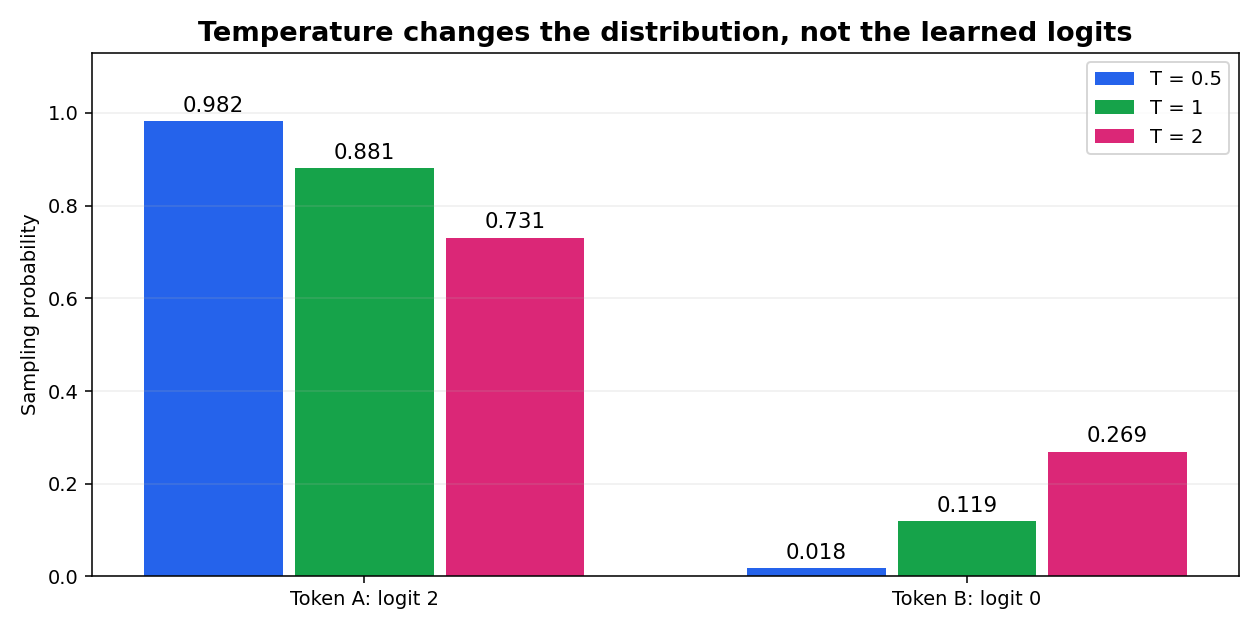

The formula requires a positive nonzero temperature. Greedy decoding is a separate selection rule, often described as a limiting low-temperature behavior rather than substituting zero into the formula.

Temperature rescales preferences among tokens. It does not add evidence, update the model's learned parameters, or guarantee factual correctness. Increasing variability can expose different continuations while also changing error patterns.


## Work top-k and nucleus filtering with actual probabilities

Suppose a next-token distribution over candidates A through D is $[0.50,0.25,0.15,0.10]$.

Top-k with $k=2$ retains A and B. Their mass is 0.75, so sampling probabilities after renormalization become $[2/3,1/3,0,0]$.

Nucleus, or top-p, filtering sorts candidates by probability and retains a smallest leading set whose mass reaches the chosen threshold. For $p=0.8$, A and B reach only 0.75, so C is also included. The retained mass is 0.90, giving probabilities approximately $[0.555556,0.277778,0.166667,0]$.

| Rule | Retained candidates | Renormalized probabilities |
| --- | --- | --- |
| Top-2 | A, B | $[0.666667,0.333333]$ |
| Top-p, threshold 0.8 | A, B, C | $[0.555556,0.277778,0.166667]$ |

The filtering order relative to temperature must be specified because temperature changes the probabilities and therefore the nucleus. Boundary and tie policies can vary; this table uses the stated smallest-prefix convention.

Filtering changes the distribution used to select a token. It is not the original unfiltered model likelihood and should not be substituted into held-out loss comparisons without explicitly changing the evaluation definition.


## Define stopping, context, and document boundaries

Generation needs a stopping policy, such as an EOS token or maximum number of new tokens. The context budget constrains which prefix representations can be supplied, and truncation can discard important instructions or evidence.

| Decision | Why it matters |
| --- | --- |
| BOS/EOS convention | Defines sequence starts and endings |
| Maximum context | Limits available history |
| Maximum new tokens | Bounds the continuation |
| Truncation policy | Determines which history is removed |
| Multiple packed documents | Determines cross-document visibility and labels |

When packing documents into a training example, decide whether tokens can attend across document boundaries and whether transitions across those boundaries have targets. An EOS marker and a block-diagonal visibility policy are different choices. The task objective should make the intended boundary behavior explicit.

For padded batches, exclude artificial keys and labels appropriately. A causal mask only controls time relationships; it does not by itself declare that a token is padding. Future-visibility, padding, document boundaries, and loss weighting are related but distinct contracts.


## Calculate perplexity and compare it under matching conditions

For mean next-token negative log likelihood $L$ using natural logs, perplexity is $e^L$. With conditional probabilities $[0.8,0.6,0.5]$ from the earlier example, $L\approx0.475705$ and perplexity is approximately 1.609149.

A uniform distribution over four tokens has loss $\ln4$ and perplexity four. A perfect probability-one prediction would have loss zero and perplexity one. Real finite logits generally produce probabilities strictly between zero and one.

| Comparison requirement | Reason |
| --- | --- |
| Same target corpus | Different texts have different difficulty |
| Same tokenizer or an explicitly normalized protocol | Tokens define the prediction events |
| Same context availability | More visible history can change likelihood |
| Same valid-target weighting | Padding and averaging alter the score |

Lower held-out perplexity indicates better predictive fit under that evaluation. It does not directly establish correctness on factual questions, quality of long generations, or success at an application's specific tasks. Those require their own representative evaluations.


## Compare causal and bidirectional adaptation interfaces

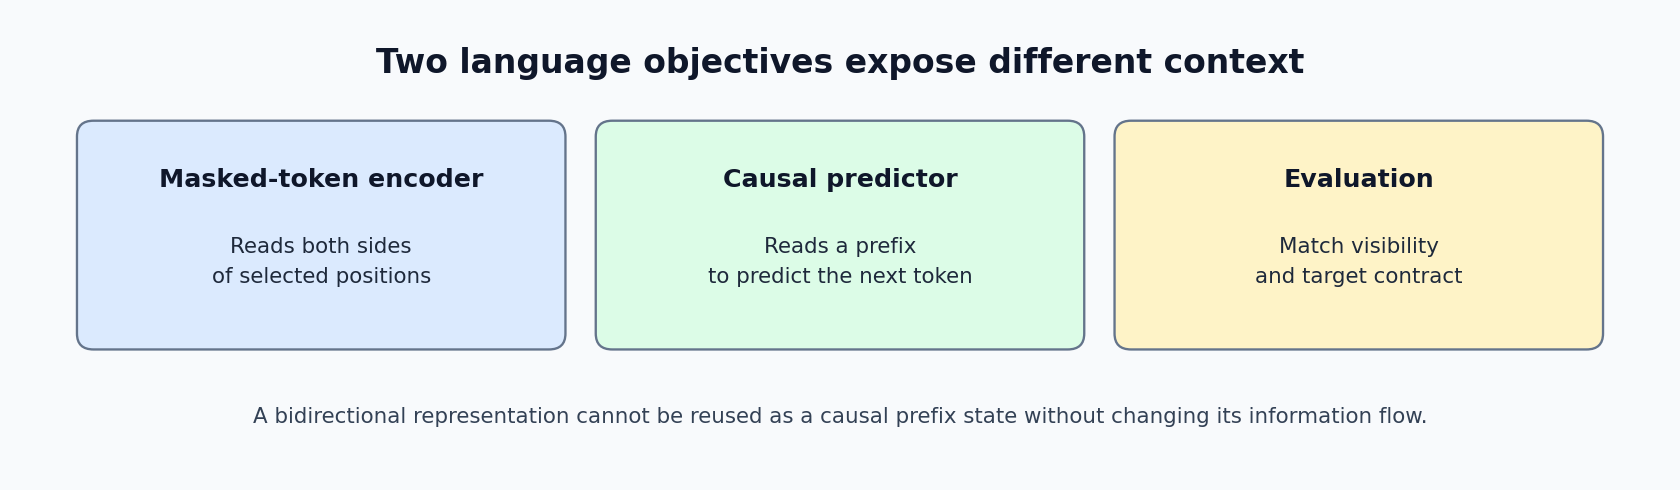

A causal pretrained backbone can be adapted with labeled examples, additional heads, or further next-token training on task-formatted sequences. Prompting supplies context at use time; fine-tuning changes parameters. These are different operations even when both influence the output.

For task-formatted training, specify which positions contribute to the loss. A response-only objective might ignore prompt labels while retaining prompt tokens as context. An all-token objective trains on both prompt and response targets. They are not interchangeable.

A bidirectional encoder is suited to representing an available complete input; a causal backbone is suited to prefix-conditioned outputs. Either can support classification with an appropriate readout. Architecture labels do not automatically decide which task has the best held-out result.

Use the same task split and information availability when comparing models, and preserve tokenizer, position, and loss policies alongside the trained weights.


## Interpret the companion and diagnose common errors

The opening mechanics example performs one forward/backward pass and checks shifted targets, logit shape, finite loss, and embedding gradients. The complete project that follows adds repeated optimization, validation-based checkpoint selection, held-out evaluation, a unigram baseline, and autoregressive generation.

| Symptom | First investigation |
| --- | --- |
| Very low loss before learning | Target leakage or incorrect shifting |
| Earlier logits change with future-token edits | Causal mask and upstream operations |
| Loss compares unexpected tokens | Flattening order and target alignment |
| Good likelihood, poor generated continuation | Free-running evaluation and selection policy |
| Cache changes deterministic predictions | Position offsets, masks, and reused tensors |
| Reported perplexities conflict | Tokenizer, context, corpus, and averaging |

To make a learning experiment, add varied independent examples, optimizer updates, and a held-out protocol. To test generation, supply a prefix and evaluate complete continuations with defined sampling and stopping rules. Do not infer a useful language capability from one initialized gradient calculation.


## Practice the prefix contract and retain the distinction

1. For tokens `[A,B,C,D]`, what are the inputs and targets in the companion's shift style?
2. Why does the causal mask allow a position to read its own supplied input token?
3. What are top-2 probabilities after filtering $[0.6,0.3,0.1]$?
4. What is perplexity if mean natural-log loss is $\ln3$?
5. Does increasing temperature make the model better informed?

**Answers.** Inputs are `[A,B,C]`, targets `[B,C,D]`. The supplied current token belongs to the prefix for predicting the next token. The top-two probabilities renormalize to $[2/3,1/3]$. Perplexity is three. Temperature changes the sampling distribution without supplying new information.

**Remember:** causal language learning predicts the next token from a permitted prefix. Training supplies true history; generation builds its own history. Probability fit, sampling behavior, and application usefulness are related questions that need separate evidence.

Continue with [Convolution by Hand](33_Convolution_by_Hand_Notes.ipynb), which returns to spatial models and calculates a shared local filter directly.


## Complete project walkthrough: a learned next-token Transformer

<div style="background:#DBEAFE;border-left:6px solid #2563EB;padding:16px;border-radius:8px"><b>From components to a complete model.</b> The companion now connects lessons 26–32 through a trained, validation-selected causal Transformer and an autoregressive generation loop. Its corpus is local, small, and deliberately controlled.</div>

We enumerate all 256 combinations of four colors, animals, actions, and locations into sentences such as `the blue bird walks near the hill .`. Split whole sentences first: 192 train, 32 validation, 32 test. The training vocabulary adds PAD, BOS, EOS, and UNK to observed words, giving 23 entries. Held-out combinations use familiar words but contain no exact training sentence.

| Stage | Shape | Meaning |
|---|---|---|
| Encoded training sentences | `[192,10]` | BOS + eight word/punctuation tokens + EOS |
| Shifted inputs and labels | `[192,9]` each | Predict one position ahead |
| Token + position vectors | `[192,9,32]` | Learned content and ordered coordinates |
| Two-head causal attention | `[192,9,32]` | Two width-16 heads combined |
| Feed-forward intermediate | `[192,9,64]` | Nonlinear per-position feature update |
| Vocabulary head | `[192,9,23]` | Next-token logits |
| Loss | Scalar | Mean over non-PAD targets |

The model has 10,391 parameters. It uses pre-normalized residual sublayers, a final LayerNorm, and no dropout. Attention masks prevent future visibility; key-padding masks and ignored target IDs serve separate roles. A future-token perturbation check compares earlier logits before training, ensuring the mask enforces the intended dependency rule.


### Fit, select, then evaluate

AdamW uses learning rate 0.004 and weight decay 0.01 for 100 full-batch updates. Gradients are clipped to norm 1.0. Training and validation NLL are measured without updates after each epoch. Deep-copied parameter values preserve the lowest-validation-loss checkpoint, which is restored before final test evaluation.

The unigram baseline estimates target frequencies from training only, using additive smoothing; PAD and BOS have zero output probability. It has no prefix information. Both models are measured on the same actual test targets, including EOS. The reported perplexity is the exponential of mean target NLL.

<div style="background:#FEF3C7;border-left:6px solid #D97706;padding:14px;border-radius:8px"><b>Why zero loss is not expected.</b> The grammar contains independently chosen content words. Before seeing a color, for example, several colors are valid. Learning the distribution and grammatical positions does not eliminate genuine ambiguity.</div>


### Generate with the same model

Generation starts with BOS and an optional known-word prefix. Each forward pass scores its final position; the selected token is appended and becomes context for the next prediction. Greedy decoding and seeded temperature sampling are both implemented. PAD, BOS, and UNK are blocked as outputs; EOS ends generation. The learned position table also supplies a hard maximum context length.

No grammar-specific decoder forces the generated sentence structure. Plausible samples provide behavioral examples, while held-out NLL supplies aggregate predictive evidence. Exact sentences may recur during generation because the finite grammar itself has only 256 combinations. This experiment does not establish factual reasoning or broad natural-language ability.


## Executed reference run: Word-token Transformer

<div style="background:#DCFCE7;border-left:6px solid #16A34A;padding:14px;border-radius:8px"><b>Measured results.</b> Selected epoch: 97. Test NLL: **0.6473**, word perplexity: **1.910**, token accuracy: **0.604**. Training-unigram test NLL: 2.6672; perplexity: 14.400. Sample: `the red dog walks near the tree .`.</div>

These outputs were obtained by running every code cell in a fresh CPU kernel with the repository’s virtual environment. They describe this fixed synthetic experiment, not performance on arbitrary real-world data.

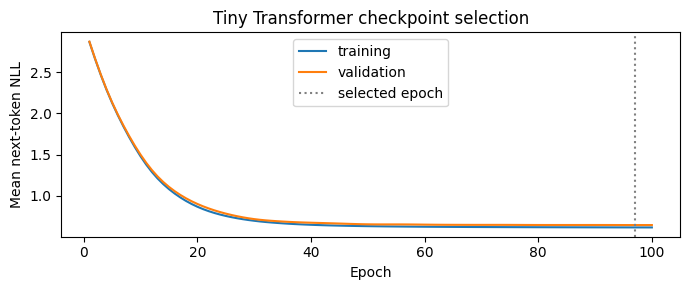
